# xRAG vs Non-xRAG Saturation Comparison

This notebook compares **xRAG token** saturation metrics to **non-xRAG baselines** (no-context, context first, context mean, all non-xRAG mean) across middle and last layers. It produces histogram figures and summary tables (effect sizes, % difference). Set `DATA_PATH_TEMPLATE` and `FIGURES_OUTPUT_DIR` in the next cell before running.

In [20]:
# Config: set paths before running (use {} for dataset: squad, trivia, hotpot)
BASE_PATH = "/app/xlong/scripts/data_preprocessing/runs/squad"
DATA_PATH_TEMPLATE = f"{BASE_PATH}/merged_features.jsonl"
FIGURES_OUTPUT_DIR = f"{BASE_PATH}/figures"


import json
import pandas as pd
from scipy.stats import ttest_ind
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 14


def load_dataset(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))

    df_features = pd.json_normalize(rows, sep=".")
    print(len(df_features))
    return df_features


def interprete_features(filepath_template, name):
    df_features = load_dataset(filepath_template.format(name))
    print(df_features.columns)
    print(f"Dataset: {name}")
    print("\n" + "="*120)
    print("HISTOGRAM VISUALIZATION: Distribution Comparison")
    print("="*120)
    plot_saturation_histograms(df_features, name)
    df_summary = print_comparison(df_features)
    summary_pivot = visualize_table(df_summary)
    return summary_pivot


def cohens_d(x, y):
    """Calculate Cohen's d effect size"""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)


def print_comparison(df_features):
    stages = ['mid', 'last']
    metric_types = ['excess_kurtosis', 'hoyer', 'spec_entropy'] # 'l2']
    
    # Stage name mapping
    stage_names = {
        'mid': 'Middle Layer',
        'last': 'Last Layer'
    }

    # Define all baseline comparisons
    baselines = {
        'No Context (first)': ('no_context_metrics', 'first'),
        'Context (first)': ('context_metrics', 'first'),
        'Context (mean)': ('context_metrics', 'mean'),
        'All Non-xRAG (mean)': ('group_metrics', 'mean')
    }

    # Build comprehensive statistics table
    results = []

    for stage in stages:
        for mtype in metric_types:
            xrag_col = f"{stage}_group_metrics.xrag_{mtype}_mean"
            
            if xrag_col not in df_features.columns:
                print(f"Missing {xrag_col} ...")
                continue
                
            xrag_vals = df_features[xrag_col].dropna().values
            
            for baseline_name, (baseline_type, stat_type) in baselines.items():
                if baseline_type == 'group_metrics':
                    nonxrag_col = f"{stage}_group_metrics.nonxrag_{mtype}_{stat_type}"
                else:
                    nonxrag_col = f"{stage}_{baseline_type}.{mtype}_{stat_type}"
                
                if nonxrag_col not in df_features.columns:
                    continue
                
                nonxrag_vals = df_features[nonxrag_col].dropna().values
                
                # Calculate statistics
                xrag_mean = np.mean(xrag_vals)
                xrag_std = np.std(xrag_vals, ddof=1)
                nonxrag_mean = np.mean(nonxrag_vals)
                nonxrag_std = np.std(nonxrag_vals, ddof=1)
                
                # Effect size (Cohen's d)
                effect_size = cohens_d(xrag_vals, nonxrag_vals)
                
                # Statistical test (t-test)
                t_stat, p_value = ttest_ind(xrag_vals, nonxrag_vals)
                
                # Percent difference
                pct_diff = ((xrag_mean - nonxrag_mean) / abs(nonxrag_mean)) * 100
                
                results.append({
                    'Stage': stage_names[stage],
                    'Metric': mtype.replace('_', ' ').title(),
                    'Baseline': baseline_name,
                    'xRAG Mean': xrag_mean,
                    'xRAG Std': xrag_std,
                    'Non-xRAG Mean': nonxrag_mean,
                    'Non-xRAG Std': nonxrag_std,
                    'Difference': xrag_mean - nonxrag_mean,
                    '% Diff': pct_diff,
                    "Cohen's d": effect_size,
                    'p-value': p_value,
                    'Significant': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
                })

    df_summary = pd.DataFrame(results)
    return df_summary


def plot_saturation_histograms(df_features, dataset_name):
    """Create histogram plots comparing xRAG vs non-xRAG saturation statistics"""
    stages = ['mid', 'last']
    metric_types = ['excess_kurtosis', 'hoyer', 'spec_entropy']
    metric_labels = {
        'excess_kurtosis': 'Excess Kurtosis',
        'hoyer': 'Hoyer Sparsity',
        'spec_entropy': 'Spectral Entropy'
    }
    
    # Define baseline for comparison (using 'All Non-xRAG (mean)' as primary baseline)
    baseline_type = 'group_metrics'
    stat_type = 'mean'
    
    n_stages = len(stages)
    n_metrics = len(metric_types)
    
    fig, axes = plt.subplots(n_stages, n_metrics, figsize=(18, 10))
    if n_stages == 1:
        axes = axes.reshape(1, -1)
    if n_metrics == 1:
        axes = axes.reshape(-1, 1)
    
    # Dataset labels
    dataset_labels = {
        'squad': 'SQuAD',
        'trivia': 'TriviaQA',
        'hotpot': 'HotpotQA'
    }
    dataset_label = dataset_labels.get(dataset_name, dataset_name.upper())
    
    # Stage labels for y-axis
    stage_labels = {
        'mid': 'Middle Layer',
        'last': 'Last Layer'
    }
    
    for stage_idx, stage in enumerate(stages):
        for metric_idx, mtype in enumerate(metric_types):
            ax = axes[stage_idx, metric_idx]
            
            # Set black borders for subplot
            for spine in ax.spines.values():
                spine.set_color('black')
                spine.set_linewidth(1.5)
            
            # Get xRAG values
            xrag_col = f"{stage}_group_metrics.xrag_{mtype}_mean"
            if xrag_col not in df_features.columns:
                print(f"Missing {xrag_col} ...")
                ax.text(0.5, 0.5, 'Data not available', 
                       ha='center', va='center', transform=ax.transAxes)
                continue
            
            xrag_vals = df_features[xrag_col].dropna().values
            
            # Get non-xRAG values
            nonxrag_col = f"{stage}_group_metrics.nonxrag_{mtype}_{stat_type}"
            if nonxrag_col not in df_features.columns:
                print(f"Missing {xrag_col} ...")
                ax.text(0.5, 0.5, 'Data not available', 
                       ha='center', va='center', transform=ax.transAxes)
                continue
            
            nonxrag_vals = df_features[nonxrag_col].dropna().values
            
            # Calculate means for vertical lines
            xrag_mean = np.mean(xrag_vals)
            nonxrag_mean = np.mean(nonxrag_vals)
            
            # Create histograms
            bins = np.linspace(
                min(np.min(xrag_vals), np.min(nonxrag_vals)),
                max(np.max(xrag_vals), np.max(nonxrag_vals)),
                50
            )
            
            ax.hist(nonxrag_vals, bins=bins, alpha=0.6, label='Non-xRAG', 
                   color='#FF6B6B',  linewidth=0.5)
            ax.hist(xrag_vals, bins=bins, alpha=0.6, label='xRAG', 
                   color='#5ED1FF',  linewidth=0.5)
            
            # Add vertical lines for means
            ax.axvline(nonxrag_mean, color='#FF6B6B', linestyle='--', linewidth=2, 
                      label=f'Non-xRAG mean') #: {nonxrag_mean:.3f}')
            ax.axvline(xrag_mean, color='#5ED1FF', linestyle='--', linewidth=2, 
                      label=f'xRAG mean') #: {xrag_mean:.3f}')
            
            # Format x-axis ticks to prevent overlap, especially for spectral entropy
            if mtype == 'spec_entropy':
                # For spectral entropy, use fewer ticks and format with fewer decimals
                ax.tick_params(axis='x', rotation=0)
                # Limit number of ticks
                ax.locator_params(axis='x', nbins=5)
                # Format tick labels
                ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
            else:
                # For other metrics, use standard formatting
                ax.tick_params(axis='x', rotation=0)
                ax.locator_params(axis='x', nbins=6)
            
            if stage_idx != 0:
                ax.set_xlabel(metric_labels[mtype], fontweight='bold')
            
            # Set ylabel only for first column, add stage label on the left
            if metric_idx == 0:
                ax.set_ylabel('Frequency', fontweight='bold')
                # Add stage label on the left side (like LLM-Dependent in consolidated plot)
                ax.text(-0.18, 0.5, stage_labels[stage], 
                       transform=ax.transAxes, fontsize=12, fontweight='bold',
                       va='center', ha='center', rotation=90)
            else:
                ax.set_ylabel('')
            
            # Show legend only on first subplot
            if stage_idx == 0 and metric_idx == 0:
                ax.legend(loc='upper right', framealpha=0.95)
            
            ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()
    
    # Save figure
    output_dir = Path(FIGURES_OUTPUT_DIR)
    output_dir.mkdir(exist_ok=True, parents=True)
    filename_base = output_dir / f'saturation_histograms_{dataset_name}'
    fig.savefig(f'{filename_base}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'{filename_base}.pdf', bbox_inches='tight')
    print(f"Saved: {filename_base}.png")
    print(f"Saved: {filename_base}.pdf")
    
    return fig


def visualize_table(df_summary):
    # Create a styled summary table showing only key metrics
    summary_pivot = df_summary.pivot_table(
        index=['Stage', 'Metric'],
        columns='Baseline',
        values=['% Diff', "Cohen's d"],
        aggfunc='first'
    )

    # Display styled table with color coding
    def highlight_effect_size(val):
        """Color code based on effect size magnitude"""
        if pd.isna(val):
            return ''
        abs_val = abs(val)
        if abs_val >= 0.8:
            return 'background-color: #ff6b6b; font-weight: bold'  # Large effect - red
        elif abs_val >= 0.5:
            return 'background-color: #ffd93d; font-weight: bold'  # Medium effect - yellow
        elif abs_val >= 0.2:
            return 'background-color: #a8e6cf'  # Small effect - green
        else:
            return 'background-color: #e8e8e8'  # Negligible - gray

    def highlight_pct_diff(val):
        """Color code based on percentage difference"""
        if pd.isna(val):
            return ''
        abs_val = abs(val)
        if abs_val >= 20:
            return 'background-color: #ff6b6b; font-weight: bold'
        elif abs_val >= 10:
            return 'background-color: #ffd93d; font-weight: bold'
        elif abs_val >= 5:
            return 'background-color: #a8e6cf'
        else:
            return 'background-color: #e8e8e8'

    print("="*120)
    print("VISUAL SUMMARY: Color-coded by effect magnitude")
    print("="*120)
    print("\nCohen's d (Effect Size):")
    print("  🔴 Red = Large (|d| ≥ 0.8)")
    print("  🟡 Yellow = Medium (|d| ≥ 0.5)")
    print("  🟢 Green = Small (|d| ≥ 0.2)")
    print("  ⚪ Gray = Negligible")
    print()

    # Display the pivot table
    styled_cohens = summary_pivot["Cohen's d"].style.applymap(highlight_effect_size).format("{:.3f}")
    display(styled_cohens)

    print("\n% Difference:")
    print("  🔴 Red = Large (≥ 20%)")
    print("  🟡 Yellow = Medium (≥ 10%)")
    print("  🟢 Green = Small (≥ 5%)")
    print("  ⚪ Gray = Negligible")
    print()

    styled_pct = summary_pivot['% Diff'].style.applymap(highlight_pct_diff).format("{:.1f}%")
    display(styled_pct)

    print("="*120)
    return summary_pivot

100
Index(['id', 'gold_answer', 'task_type', 'input_len', 'xrag_pos',
       'mid_layer_index', 'last_layer_index', 'overflow_label',
       'mid_context_metrics.l2_first', 'mid_context_metrics.l2_mean',
       ...
       'attn_last.nonxrag_in_to_xrag_mean_std', 'attn_last.xrag_in_share_mean',
       'attn_last.xrag_in_share_max', 'attn_last.xrag_in_share_min',
       'attn_last.xrag_in_share_std', 'attn_last.xrag_out_entropy_mean',
       'attn_last.xrag_out_entropy_max', 'attn_last.xrag_out_entropy_min',
       'attn_last.xrag_out_entropy_std',
       'attn_last.xrag_out_xrag_vs_nonx_ratio_mean'],
      dtype='object', length=242)
Dataset: squad

HISTOGRAM VISUALIZATION: Distribution Comparison


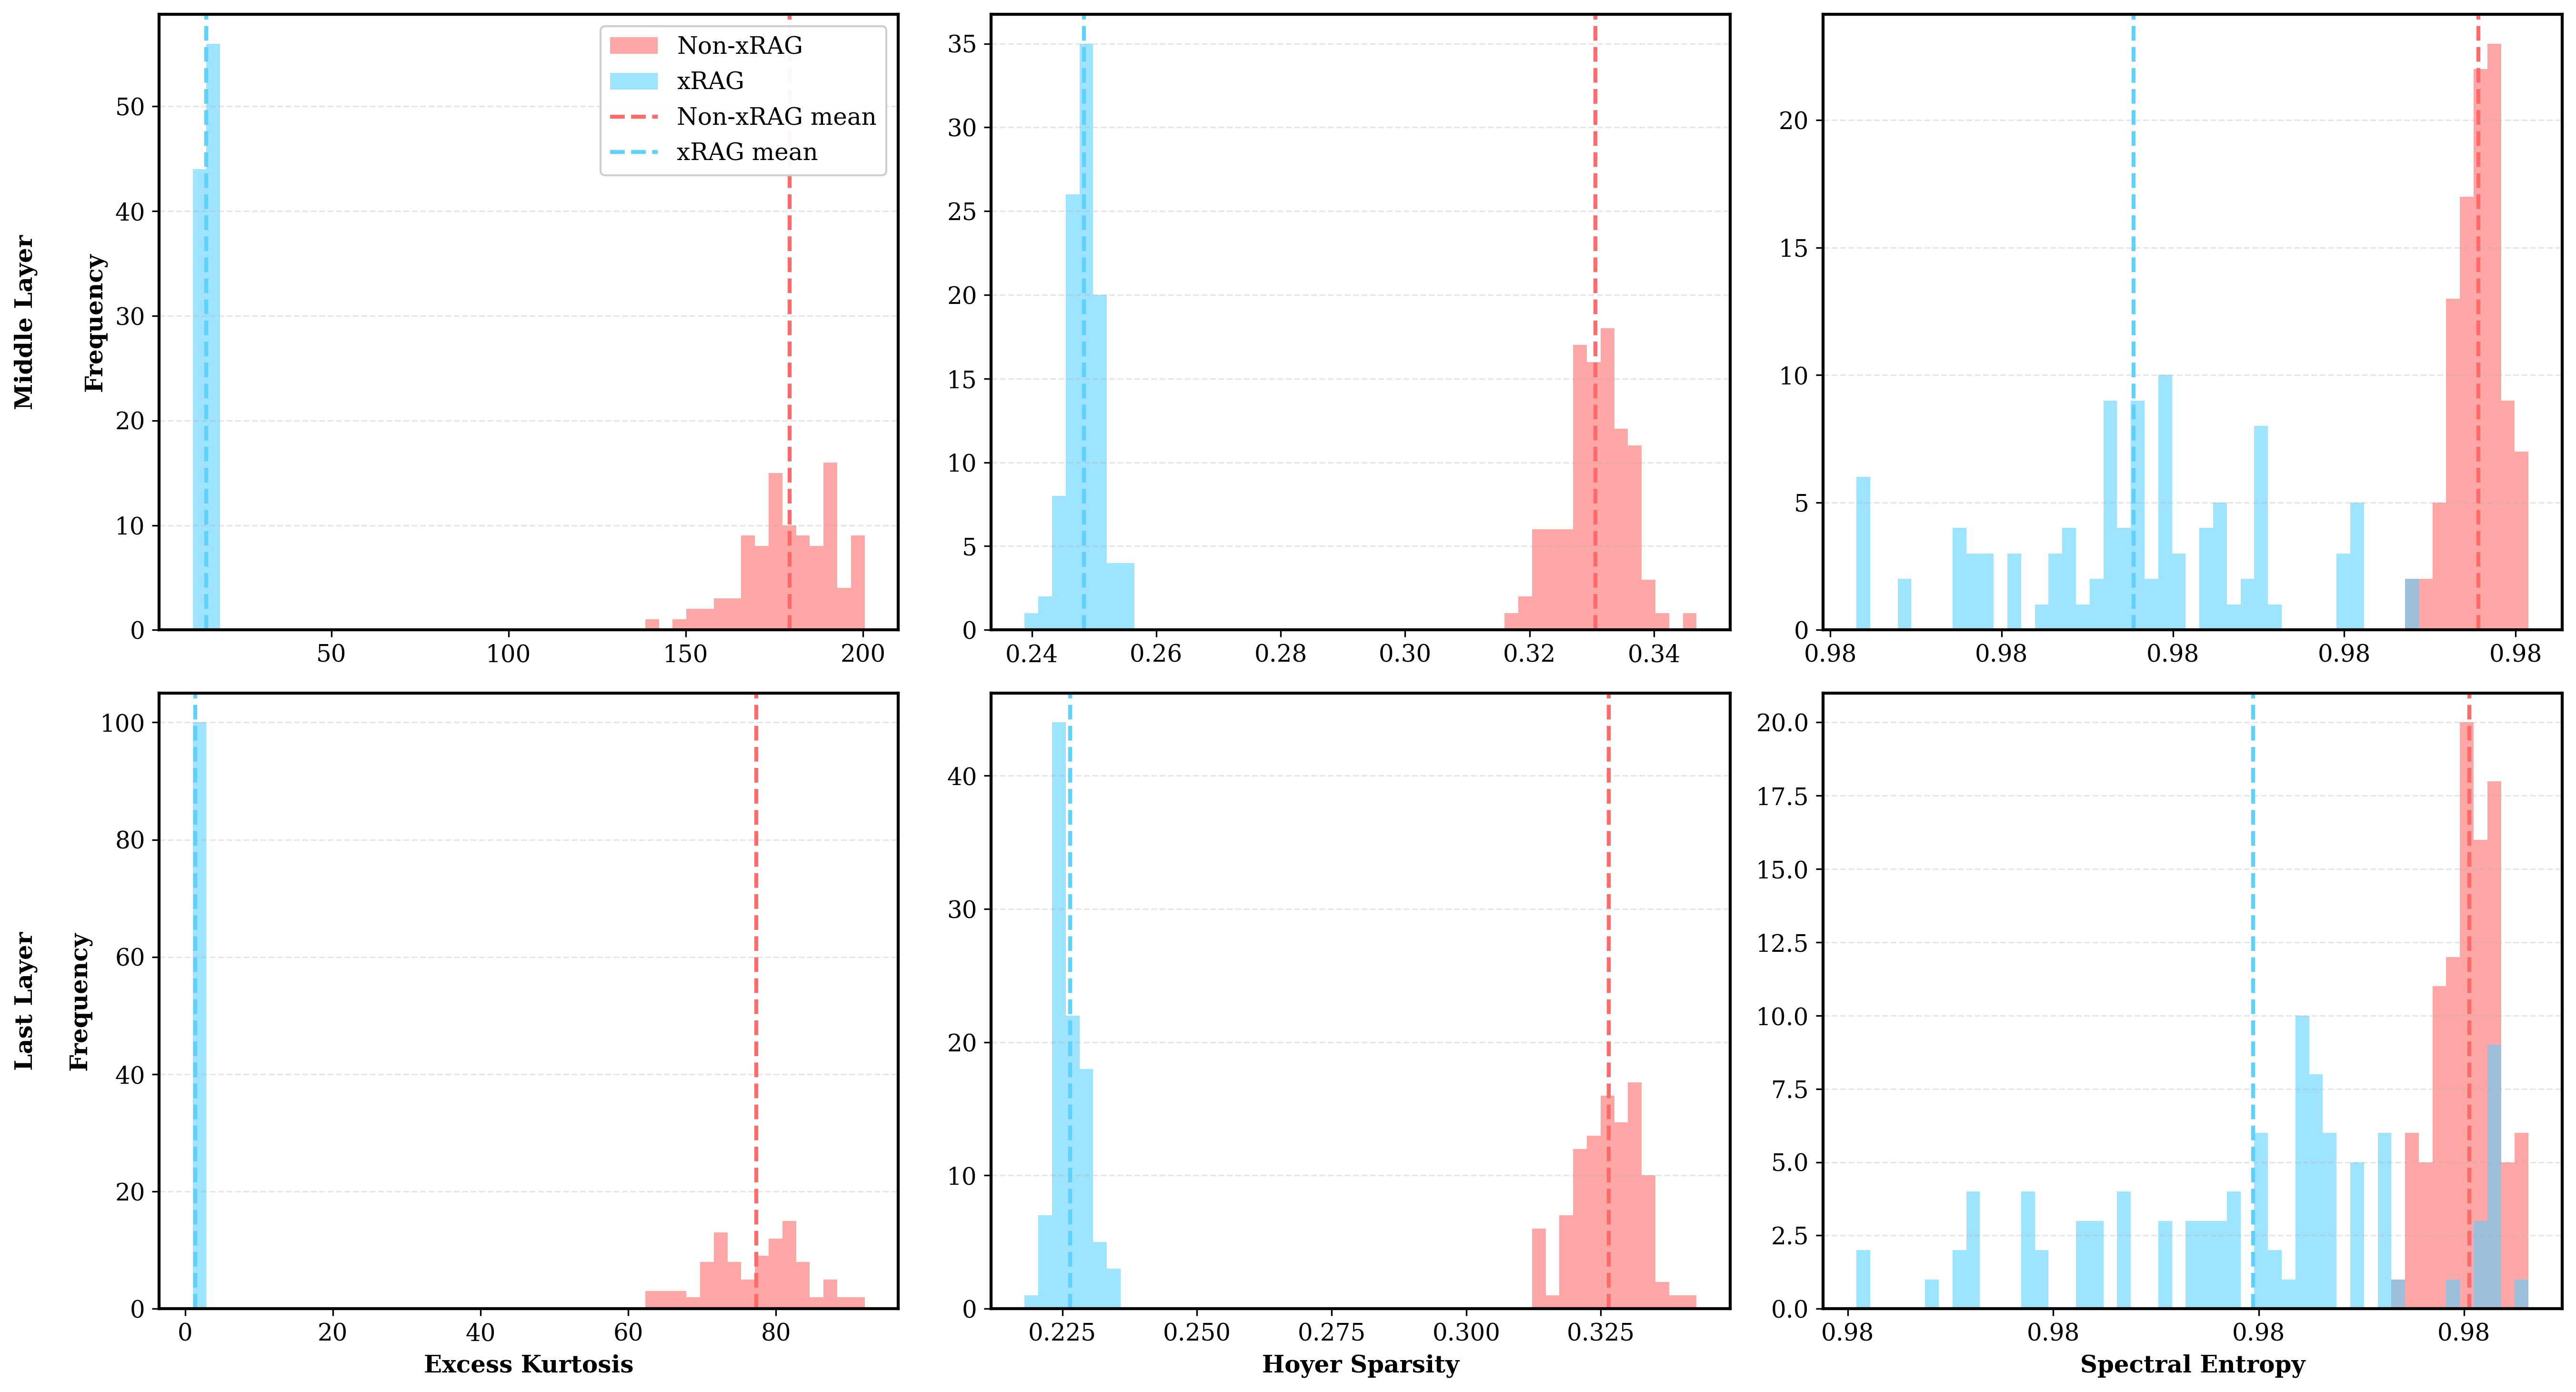

Saved: /app/xlong/scripts/data_preprocessing/runs/squad/figures/saturation_histograms_squad.png
Saved: /app/xlong/scripts/data_preprocessing/runs/squad/figures/saturation_histograms_squad.pdf
VISUAL SUMMARY: Color-coded by effect magnitude

Cohen's d (Effect Size):
  🔴 Red = Large (|d| ≥ 0.8)
  🟡 Yellow = Medium (|d| ≥ 0.5)
  🟢 Green = Small (|d| ≥ 0.2)
  ⚪ Gray = Negligible




% Difference:
  🔴 Red = Large (≥ 20%)
  🟡 Yellow = Medium (≥ 10%)
  🟢 Green = Small (≥ 5%)
  ⚪ Gray = Negligible



% Diff                  \
Baseline                     All Non-xRAG (mean) Context (first)   
Stage        Metric                                                
Last Layer   Excess Kurtosis          -98.196971      -98.570107   
             Hoyer                    -30.641872      -30.965494   
             Spec Entropy              -0.053510      -87.084028   
Middle Layer Excess Kurtosis          -91.823868      -20.976457   
             Hoyer                    -24.865451      -21.480562   
             Spec Entropy              -0.102471      -87.086757   

                                                                \
Baseline                     Context (mean) No Context (first)   
Stage        Metric                                              
Last Layer   Excess Kurtosis     -93.043014         -78.423939   
             Hoyer               -18.271840          -7.090859   
             Spec Entropy        -87.065537         -87.039256   
Middle Layer Excess Kurtosis     -32.536037          34.248797   
             Hoyer               -20.825068         -19.580364   
             Spec Entropy        -87.069093         -87.063688   

                                       Cohen's d                  \
Baseline                     All Non-xRAG (mean) Context (first)   
Stage        Metric                                                
Last Layer   Excess Kurtosis          -16.501230       -1.368175   
             Hoyer                    -20.724784       -2.409275   
             Spec Entropy              -1.882936     -562.175569   
Middle Layer Excess Kurtosis          -18.235364       -0.821660   
             Hoyer                    -19.285500       -6.035739   
             Spec Entropy              -3.641354     -891.665332   

                                                                
Baseline                     Context (mean) No Context (first)  
Stage        Metric                                             
Last Layer   Excess Kurtosis      -5.394229         -40.795618  
             Hoyer                -7.796259          -7.547936  
             Spec Entropy      -4811.701216      -22237.399492  
Middle Layer Excess Kurtosis      -1.893714           3.464568  
             Hoyer                -7.479584         -28.417544  
             Spec Entropy      -5356.643150      -24221.193572

In [21]:
interprete_features(DATA_PATH_TEMPLATE, "squad")

In [ ]:
interprete_features(DATA_PATH_TEMPLATE, "trivia")

In [ ]:
interprete_features(DATA_PATH_TEMPLATE, "hotpot")